이 글은 FBref의 한국 대표팀 경기 기록으로 **파울루 벤투**(2022 월드컵 사이클, 2019–2022)와 **홍명보 2기**(2024–현재)의 전술 성향을 데이터로 비교합니다.

> **데이터·범위.** FBref Korea Republic(Scores & Fixtures). 벤투 30경기, 홍명보 17경기(2024-09 이후).
> ⚠️ 상대 수준이 다르고(벤투에 약체 예선 다수), 점유율은 벤투의 경우 2022 월드컵 4경기만 제공됩니다. 단순 평균보다 **포메이션 구성**과 **월드컵 본선(동일 무대)** 비교가 더 신뢰도 높습니다.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

# ── 통일 테마 ─────────────────────────────────────────────
sns.set_theme(style='white', font='AppleGothic')
mpl.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 140, 'savefig.bbox': 'tight',
    'axes.unicode_minus': False,
    'axes.titlesize': 15, 'axes.titleweight': 'bold', 'axes.titlepad': 14,
    'axes.labelsize': 11, 'axes.labelcolor': '#374151',
    'axes.edgecolor': '#e5e7eb', 'axes.linewidth': 1.0,
    'xtick.color': '#6b7280', 'ytick.color': '#6b7280',
    'text.color': '#111827', 'font.size': 11, 'legend.frameon': False,
})
_set2 = sns.color_palette('Set2')
BENTO, HONG = _set2[0], _set2[1]
PAL = {'벤투': BENTO, '홍명보': HONG}

def text_on(color):
    r, g, b = mpl.colors.to_rgb(color)
    return 'white' if (0.299*r + 0.587*g + 0.114*b) < 0.62 else '#374151'

def finish(ax, title, sub=None, grid='y'):
    ax.set_title(title, loc='left')
    if sub:
        ax.text(0, 1.015, sub, transform=ax.transAxes, fontsize=9.5,
                color='#6b7280', va='bottom')
    ax.grid(axis=grid, color='#eef1f5', linewidth=1)
    ax.set_axisbelow(True)
    sns.despine(ax=ax, left=(grid=='y'), bottom=False)

p = Path('data/korea_fbref/korea_matches.csv')
if not p.exists():
    p = Path('notebooks/data/korea_fbref/korea_matches.csv')
df = pd.read_csv(p)
df['poss'] = pd.to_numeric(df['poss'], errors='coerce')
df['감독'] = df['coach'].map({'Bento': '벤투', 'Hong': '홍명보'})
df['date'] = pd.to_datetime(df['date'])
print(df.groupby('감독').size().to_dict())

{'벤투': 30, '홍명보': 17}


## 1. 포메이션 구성

포백 계열을 청록 계열, 스리백(3-4-3)을 자주색으로 칠했습니다. 벤투는 포백 안에서 여러 형태를 두루 쓴 반면, 홍명보는 4-2-3-1과 3-4-3 두 가지에 집중했고 그중 **3-4-3(자주) 비중이 큽니다.**

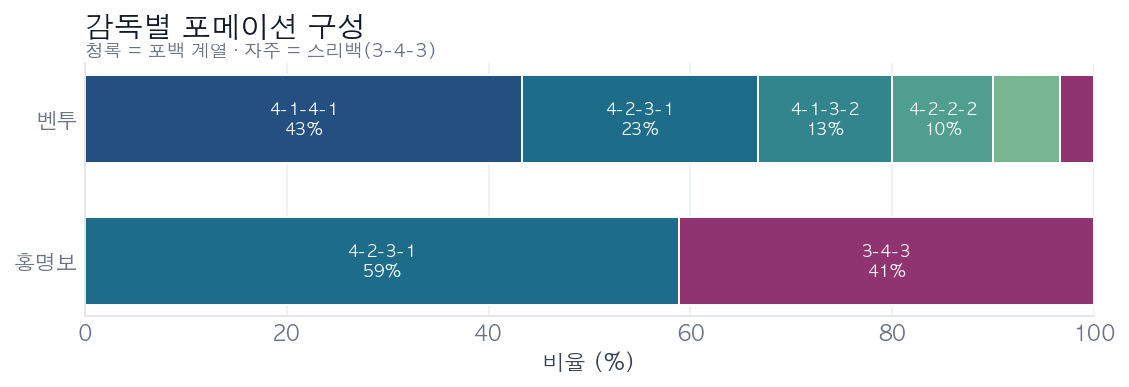

In [2]:
form_order = ['4-1-4-1', '4-2-3-1', '4-1-3-2', '4-2-2-2', '4-4-1-1', '3-4-3']
_cool = sns.color_palette('crest', 5)
form_pal = {'4-1-4-1': _cool[4], '4-2-3-1': _cool[3], '4-1-3-2': _cool[2],
            '4-2-2-2': _cool[1], '4-4-1-1': _cool[0], '3-4-3': sns.color_palette('flare', 6)[4]}

# 감독별 포메이션 비율(%) 누적 가로 막대
ct = (pd.crosstab(df['감독'], df['formation'], normalize='index')[form_order] * 100)
ct = ct.reindex(['벤투', '홍명보'])
fig, ax = plt.subplots(figsize=(8.2, 2.9))
left = pd.Series(0.0, index=ct.index)
for f in form_order:
    ax.barh(ct.index, ct[f], left=left, color=form_pal[f], label=f, height=0.62)
    for y, (v, l) in enumerate(zip(ct[f], left)):
        if v >= 7:
            ax.text(l + v/2, y, f'{f}\n{v:.0f}%', ha='center', va='center',
                    fontsize=8.5, color=text_on(form_pal[f]), fontweight='bold')
    left += ct[f]
ax.set_xlim(0, 100); ax.set_xlabel('비율 (%)'); ax.invert_yaxis()
ax.tick_params(length=0)
finish(ax, '감독별 포메이션 구성', '청록 = 포백 계열 · 자주 = 스리백(3-4-3)', grid='x')
plt.tight_layout(); plt.show()

## 2. 포메이션 전환 시점

시간 순으로 보면 홍명보의 **3-4-3 전환**이 2026년 들어 또렷합니다(그 전 예선은 4-2-3-1).

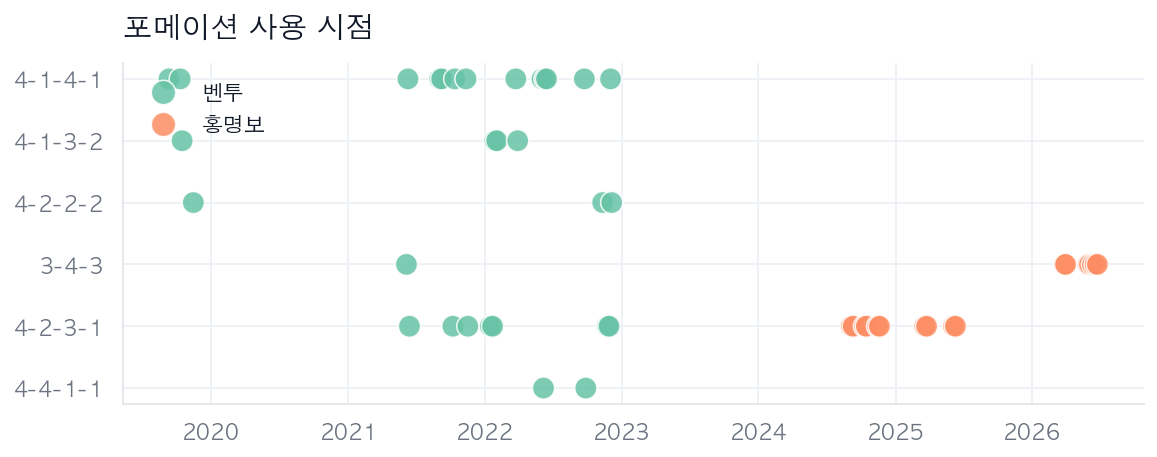

In [3]:
fig, ax = plt.subplots(figsize=(8.4, 3.4))
sns.scatterplot(data=df, x='date', y='formation', hue='감독', palette=PAL,
                s=130, alpha=0.85, edgecolor='white', linewidth=0.8, ax=ax)
ax.set_xlabel(''); ax.set_ylabel('')
ax.legend(title='', loc='upper left', markerscale=1.1)
finish(ax, '포메이션 사용 시점', grid='both')
ax.grid(axis='both', color='#eef1f5', linewidth=1)
plt.tight_layout(); plt.show()

## 3. 월드컵 본선 맞대결

상대 수준이 비슷한 월드컵 본선만 비교합니다(점유율과 득실은 스케일이 달라 패널을 나눴습니다).

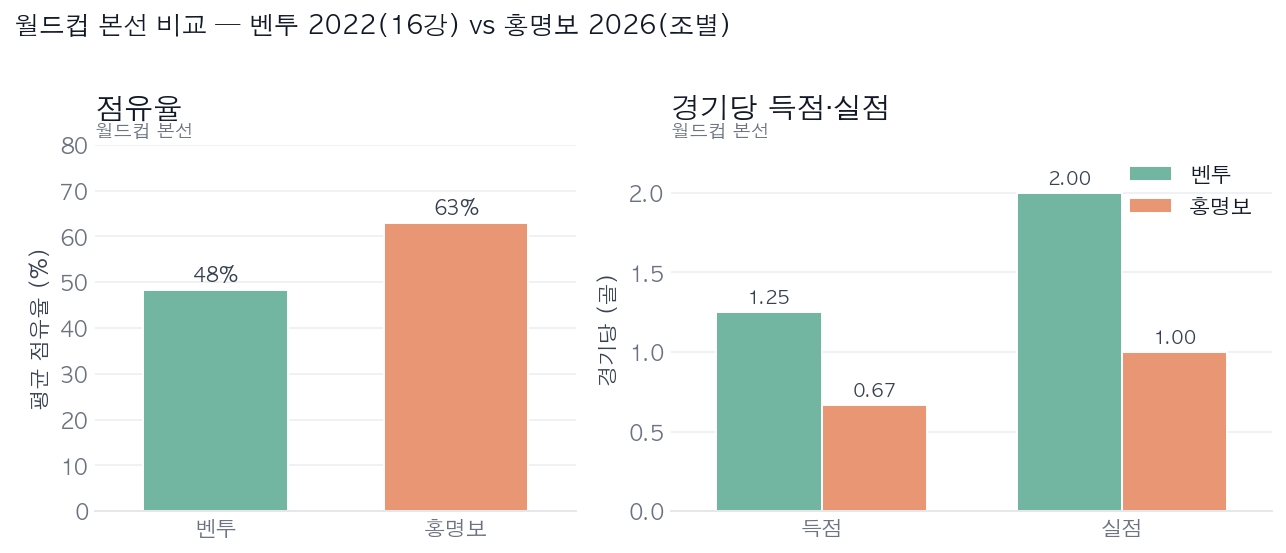

In [4]:
wc = df[df['comp'] == 'WorldCup']
gp = wc.groupby('감독', as_index=False)['poss'].mean()
gg = (wc.groupby('감독', as_index=False)
        .agg(득점=('gf', 'mean'), 실점=('ga', 'mean'))
        .melt('감독', var_name='지표', value_name='값'))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.2, 4),
                             gridspec_kw={'width_ratios': [1, 1.25]})
sns.barplot(data=gp, x='감독', y='poss', hue='감독', palette=PAL,
            legend=False, width=0.6, ax=a1)
for _c in a1.containers:
    a1.bar_label(_c, fmt='%.0f%%', padding=3, fontsize=10, color='#374151')
a1.set_ylim(0, 80); a1.set_xlabel(''); a1.set_ylabel('평균 점유율 (%)')
a1.tick_params(length=0)
finish(a1, '점유율', '월드컵 본선')

sns.barplot(data=gg, x='지표', y='값', hue='감독', palette=PAL, width=0.7, ax=a2)
for c in a2.containers:
    a2.bar_label(c, fmt='%.2f', padding=3, fontsize=9.5, color='#374151')
a2.set_ylim(0, 2.3); a2.set_xlabel(''); a2.set_ylabel('경기당 (골)')
a2.tick_params(length=0); a2.legend(title='', loc='upper right')
finish(a2, '경기당 득점·실점', '월드컵 본선')
fig.suptitle('월드컵 본선 비교 — 벤투 2022(16강) vs 홍명보 2026(조별)',
             x=0.005, ha='left', fontsize=13, fontweight='bold', color='#111827')
plt.tight_layout(rect=(0, 0, 1, 0.96)); plt.show()

홍명보 팀의 점유율이 더 높지만 상대(체키아·멕시코·남아공)와 벤투의 상대(우루과이·가나·포르투갈·브라질)는 수준 차가 있습니다. 결과·득점은 벤투 쪽이 앞섰습니다.

## 4. 경기별 점유율 — 상대 수준을 함께

홍명보의 높은 평균 점유율은 대부분 **약체 상대의 예선**에서 나온 값입니다. 대회별로 나눠 보면 분명합니다.

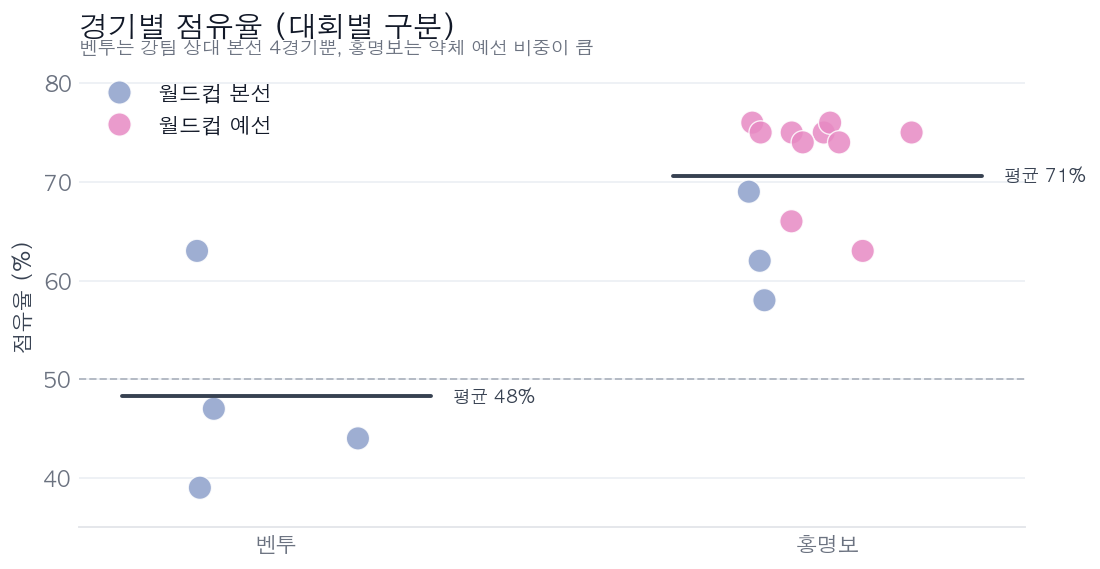

In [5]:
d = df[df['poss'].notna()].copy()
d['대회'] = d['comp'].map({'WCQ': '월드컵 예선', 'WorldCup': '월드컵 본선'})
comp_pal = {'월드컵 예선': _set2[3], '월드컵 본선': _set2[2]}
fig, ax = plt.subplots(figsize=(8, 4.2))
sns.stripplot(data=d, x='감독', y='poss', hue='대회', palette=comp_pal,
              s=12, jitter=0.16, alpha=0.85, edgecolor='white', linewidth=0.7, ax=ax)
# 감독별 평균 가로 막대
for i, c in enumerate(['벤투', '홍명보']):
    m = d[d['감독'] == c]['poss'].mean()
    ax.plot([i-0.28, i+0.28], [m, m], color='#374151', lw=2, zorder=5)
    ax.text(i+0.32, m, f'평균 {m:.0f}%', va='center', fontsize=9, color='#374151')
ax.axhline(50, color='#9ca3af', ls='--', lw=1, alpha=0.7)
ax.set_xlabel(''); ax.set_ylabel('점유율 (%)'); ax.set_ylim(35, 82)
ax.tick_params(length=0); ax.legend(title='', loc='upper left')
finish(ax, '경기별 점유율 (대회별 구분)',
       '벤투는 강팀 상대 본선 4경기뿐, 홍명보는 약체 예선 비중이 큼')
plt.tight_layout(); plt.show()

## 5. 경기 결과 분포

전체 표본 기준 승·무·패 비율입니다(상대 수준 차이 유의).

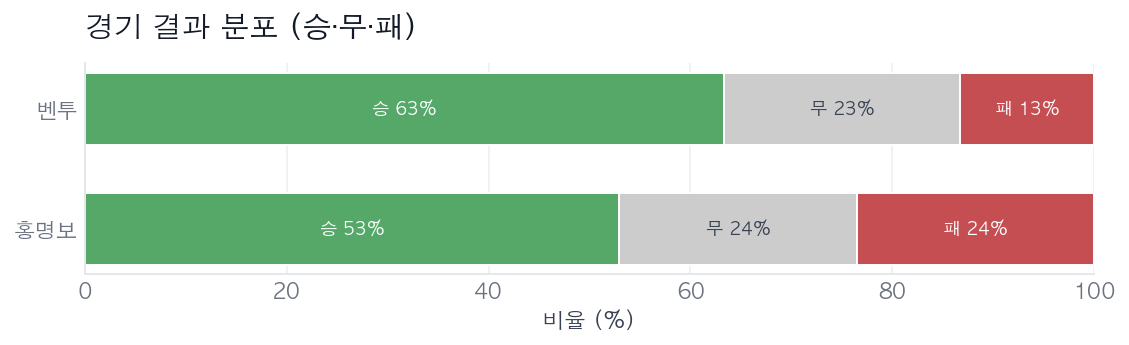

In [6]:
res_order = ['W', 'D', 'L']
res_lab = {'W': '승', 'D': '무', 'L': '패'}
_deep = sns.color_palette('deep')
res_pal = {'W': _deep[2], 'D': '#cccccc', 'L': _deep[3]}
rt = (pd.crosstab(df['감독'], df['result'], normalize='index')[res_order] * 100)
rt = rt.reindex(['벤투', '홍명보'])
fig, ax = plt.subplots(figsize=(8.2, 2.6))
left = pd.Series(0.0, index=rt.index)
for r in res_order:
    ax.barh(rt.index, rt[r], left=left, color=res_pal[r], label=res_lab[r], height=0.6)
    for y, (v, l) in enumerate(zip(rt[r], left)):
        if v >= 6:
            ax.text(l + v/2, y, f'{res_lab[r]} {v:.0f}%', ha='center', va='center',
                    fontsize=9, color=text_on(res_pal[r]), fontweight='bold')
    left += rt[r]
ax.set_xlim(0, 100); ax.set_xlabel('비율 (%)'); ax.invert_yaxis(); ax.tick_params(length=0)
finish(ax, '경기 결과 분포 (승·무·패)', grid='x')
plt.tight_layout(); plt.show()

## 정리

- **포메이션**: 벤투 = 포백 다변형, 홍명보 = 4-2-3-1에서 **스리백(3-4-3)으로 명확히 전환**.
- **점유율**: 표면상 홍명보가 높지만 상대 수준(약체 예선 비중)을 보정하면 단순 비교 불가.
- **월드컵 본선**: 벤투(16강)가 홍명보(조별 탈락)보다 결과·득점에서 앞섰다.

**한계.** 표본의 상대 수준이 다르고, FBref 국가대표 기록엔 경기별 xG가 없어 슈팅 질 비교는 못 했습니다. 패스 네트워크·압박 등 심층 분석은 이벤트 데이터(StatsBomb)가 있는 벤투 2022 월드컵에 한해 후속 글로 다룰 예정입니다.

*데이터: FBref (Sports Reference). 직접 수집·정리.*